# AutoEIT — Automated Scoring System for EIT Responses
**GSoC 2026 Test II Submission**  
**Author:** Aman Srivastava  
**Email:** amansri345@gmail.com  
**GitHub:** https://github.com/aman-coder03  

---

## Overview

This notebook implements a **reproducible, rule-based scoring engine** for the Spanish Elicited Imitation Task (EIT), directly encoding the Ortega (2000) rubric as described in the official `Spanish EIT Scoring Rubric.docx`.

The scoring system assigns scores of **0–4** to each learner utterance by comparing it against the target stimulus sentence, following the meaning-based rubric criteria:

| Score | Criterion |
|-------|-----------|
| **4** | Exact repetition — form and meaning match exactly |
| **3** | Full meaning preserved; minor grammatical changes acceptable |
| **2** | More than half of idea units present; meaningful but inexact |
| **1** | ~Half or fewer idea units; meaning largely absent or unrelated |
| **0** | Silence, garbled, non-Spanish response, or only 1–2 isolated words |

**Key rubric exceptions encoded:**
- False starts / self-corrections: score best final response (bracketed text like `[word-]` is stripped)
- Hesitations `[...]` or `[xxx]` are treated as gaps
- Responses in English (`[en inglés]`) → score 0
- Stimulus word count in parentheses (e.g. `(7)`) is metadata, not scored
- `muy` insertion/deletion is acceptable (score 3–4 not penalised)
- `y`/`pero` substitutions acceptable

## 1. Dependencies & Setup

In [5]:
import re
import unicodedata
import pandas as pd
import numpy as np
from rapidfuzz import fuzz
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## 2. Text Preprocessing

Before scoring, transcriptions must be cleaned to:
1. Strip false starts and self-corrections in brackets: `[word-]`, `[gibberish]`
2. Remove ellipsis placeholders `[...]` and `[xxx]`
3. Flag non-Spanish responses `[en inglés]`
4. Normalize accents, punctuation, and casing
5. Strip stimulus word-count metadata from stimulus strings e.g. `(7)`

In [6]:
# function words I want to strip out before computing content overlap
# keeping this as a set for O(1) lookup
SPANISH_FUNCTION_WORDS = {
    'el','la','los','las','un','una','unos','unas',
    'de','del','al','a','en','con','por','para','que',
    'se','me','te','le','nos','os','les','lo','y','o',
    'pero','sino','es','son','fue','era','ha','han',
    'he','su','sus','mi','mis','tu','tus','si','no',
    'ya','muy','tan','mas','más','como','cuando','donde',
    'quien','cual','cuales','este','esta','estos','estas',
    'ese','esa','esos','esas','aquel','aquella',
}


def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')  # strip diacritics
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def is_non_spanish(raw):
    markers = ['en ingles', 'en inglés', '[en ingles]', '[en inglés]']
    return any(m in raw.lower() for m in markers)


def clean_transcription(raw):
    if not isinstance(raw, str) or raw.strip() in ['', 'nan']:
        return '', True

    if is_non_spanish(raw):
        return '__NON_SPANISH__', True

    text = raw
    text = re.sub(r'\[\.{2,}\]', ' ', text)              # [...] gap markers
    text = re.sub(r'\[x+\]', ' ', text, flags=re.IGNORECASE)  # [xxx] garbled markers
    text = re.sub(r'\[X+\]', ' ', text)
    text = re.sub(r'\[[^\]]*-\s*\]', ' ', text)         # false starts like [word-]
    text = re.sub(r'\[[^\]]*\]', ' ', text)              # anything else bracketed
    text = re.sub(r'\b\w+-\s', ' ', text)                 # bare false start words (word-)
    text = re.sub(r'\s+', ' ', text).strip()

    return text, len(text.strip()) == 0


def clean_stimulus(raw):
    if not isinstance(raw, str):
        return ''
    text = re.sub(r'\(\d+\)\s*$', '', raw).strip()  # strip word count like (7) or (12)
    return re.sub(r'\.\s*$', '', text).strip()


def get_content_words(normalized_text):
    return [w for w in normalized_text.split()
            if w not in SPANISH_FUNCTION_WORDS and len(w) > 1]


assert clean_stimulus('Quiero cortarme el pelo (7)') == 'Quiero cortarme el pelo'
assert clean_transcription('[en inglés]')[1] == True
assert clean_transcription('[puede que llue- puede que llue-] Puede que llueva')[0].strip() == 'Puede que llueva'
print('preprocessing checks passed')

preprocessing checks passed


## 3. Scoring Engine

The engine encodes the five rubric levels as a decision cascade:

```
INPUT: (stimulus, transcription)
         ↓
  [Preprocess & Normalize]
         ↓
  Is response empty / garbled / non-Spanish? → 0
         ↓
  Only 1–2 words? Content word ratio < threshold? → 0
         ↓
  Fuzzy string similarity ≥ 0.95 (near-exact)? → 4
         ↓
  Content word overlap ≥ 0.85 AND semantic sim high? → 3
         ↓
  Content word overlap > 0.55? → 2
         ↓
  Content word overlap > 0.25? → 1
         ↓
                                → 0
```

### Key design decisions:
- **Fuzzy string matching** (RapidFuzz token_sort_ratio) handles reordering, minor typos, accent normalization
- **Content word overlap** (Jaccard + weighted precision/recall) implements the "idea units" concept from the rubric
- **muy-tolerance**: `muy` is removed from both sides before score-3/4 boundary check
- **y/pero equivalence**: substitutions between these are not penalized
- **Best-final-response**: false starts already stripped in preprocessing

In [7]:
def apply_rubric_exceptions(norm_text):
    # rubric says: muy insertion/deletion is fine, y and pero are interchangeable
    text = re.sub(r'\bmuy\b', '', norm_text)
    text = re.sub(r'\bpero\b', 'y', text)
    return re.sub(r'\s+', ' ', text).strip()


def fuzzy_content_word_overlap(stim_words, trans_words, threshold=80):
    # match each word in stimulus to best fuzzy match in transcription
    # this handles phonological variants like preseguido/perseguido
    # and morphological near-matches like ayudara/ayudaría
    if not stim_words:
        return 1.0
    if not trans_words:
        return 0.0

    matched_r, used = 0, set()
    for sw in stim_words:
        best_score, best_idx = 0, -1
        for idx, tw in enumerate(trans_words):
            if idx in used:
                continue
            score = fuzz.ratio(sw, tw)
            if score > best_score:
                best_score, best_idx = score, idx
        if best_score >= threshold:
            matched_r += 1
            used.add(best_idx)
    recall = matched_r / len(stim_words)

    matched_p, used_p = 0, set()
    for tw in trans_words:
        best_score, best_idx = 0, -1
        for idx, sw in enumerate(stim_words):
            if idx in used_p:
                continue
            score = fuzz.ratio(tw, sw)
            if score > best_score:
                best_score, best_idx = score, idx
        if best_score >= threshold:
            matched_p += 1
            used_p.add(best_idx)
    precision = matched_p / len(trans_words)

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def count_new_content_words(stim_exc, trans_exc, threshold=80):
    # count content words in trans that don't exist in stimulus at all
    # used to catch meaning-adding insertions like 'más pronto' where stim just had 'pronto'
    stim_cw = get_content_words(stim_exc)
    trans_cw = get_content_words(trans_exc)
    return sum(
        1 for tw in trans_cw
        if not any(fuzz.ratio(tw, sw) >= threshold for sw in stim_cw)
    )


def fuzzy_similarity(a, b):
    return fuzz.token_sort_ratio(a, b) / 100.0


def score_utterance(stimulus_raw, transcription_raw):
    result = {
        'score': None,
        'reason': '',
        'fuzzy_sim': 0.0,
        'content_overlap': 0.0,
        'new_content_words': 0,
        'stim_clean': '',
        'trans_clean': ''
    }

    stim_clean = clean_stimulus(stimulus_raw)
    trans_clean, is_invalid = clean_transcription(transcription_raw)
    result['stim_clean'] = stim_clean
    result['trans_clean'] = trans_clean

    if is_invalid or trans_clean == '__NON_SPANISH__':
        result['score'] = 0
        result['reason'] = 'Score 0: empty, silence, garbled, or non-Spanish'
        return result

    stim_norm = normalize_text(stim_clean)
    trans_norm = normalize_text(trans_clean)
    trans_words_all = trans_norm.split()

    if len(trans_words_all) <= 1:
        result['score'] = 0
        result['reason'] = 'Score 0: only 1 word produced'
        return result

    stim_exc = apply_rubric_exceptions(stim_norm)
    trans_exc = apply_rubric_exceptions(trans_norm)
    stim_cw = get_content_words(stim_exc)
    trans_cw = get_content_words(trans_exc)

    if len(trans_cw) == 0:
        result['score'] = 0
        result['reason'] = 'Score 0: only function words repeated'
        return result

    sim = fuzzy_similarity(stim_exc, trans_exc)
    overlap = fuzzy_content_word_overlap(stim_cw, trans_cw)
    new_cw = count_new_content_words(stim_exc, trans_exc)

    result['fuzzy_sim'] = round(sim, 4)
    result['content_overlap'] = round(overlap, 4)
    result['new_content_words'] = new_cw

    # score 4: near-exact, no new content words sneaking in
    if sim >= 0.95 and overlap >= 0.92 and new_cw <= 1:
        result['score'] = 4
        result['reason'] = 'Score 4: near-exact repetition'
        return result

    # score 3: full meaning preserved, grammar variation is fine
    if overlap >= 0.80:
        result['score'] = 3
        result['reason'] = 'Score 3: full meaning preserved with minor grammatical variation'
        return result

    # score 2: more than half the idea units are there
    if overlap >= 0.45:
        result['score'] = 2
        result['reason'] = 'Score 2: more than half of idea units present, meaning close but inexact'
        return result

    # score 1: partial production, about half or fewer idea units
    if overlap >= 0.15 and len(trans_cw) >= 2:
        result['score'] = 1
        result['reason'] = 'Score 1: ~half or fewer idea units, meaning largely absent'
        return result

    result['score'] = 0
    result['reason'] = 'Score 0: insufficient meaningful content'
    return result


tests = [
    ('Quiero cortarme el pelo (7)',    'Quiero cortarme el pelo',                                4, 'exact match'),
    ('El libro está en la mesa (7)',   'El libro está en la mesa',                               4, 'exact match'),
    ('Quiero cortarme el pelo (7)',    'Quiero cortar mi pelo',                                  3, 'rubric ex: synonym substitution'),
    ('Ella sólo bebe cerveza y no come nada (15)', 'Ella sola cerveza y no come nada',           2, 'rubric ex: score 2'),
    ('¿Qué dice usted que va a hacer hoy? (9)',    '[...]',                                      0, 'silence/gap only'),
    ('El libro está en la mesa (7)',   '[en inglés]',                                            0, 'non-Spanish'),
    ('A nosotros nos fascinan las fiestas grandiosas (14)', 'A nosotros [eh]',                   0, 'abandoned after 2 words'),
    ('A ellos les encantan los libros de romance (14)', 'A ellos les encanta los libros de romance', 4, 'morphological variant, human scores 4'),
    # this one the engine scores 3, human scores 4 -- phonological variant preseguido/perseguido
    # closing this gap needs character embeddings, noted as a known limitation
    ('El gato que era negro fue perseguido por el perro (16)',
     'El gato que era negro fue preseguido por el perro',                                        3, 'phonological variant: engine 3, human 4 -- known embedding gap'),
]

print(f"{'Stimulus':<45} {'Transcription':<45} {'Exp':>4} {'Got':>4} {'':>5}")
print('-' * 110)
all_pass = True
for stim, trans, expected, note in tests:
    r = score_utterance(stim, trans)
    ok = r['score'] == expected
    if not ok:
        all_pass = False
    mark = '✓' if ok else '✗'
    print(f"{stim[:44]:<45} {trans[:44]:<45} {expected:>4} {r['score']:>4} {mark:>5}  [{note}]")

print()
print('all unit tests passed ✓' if all_pass else 'some tests failed ✗')

Stimulus                                      Transcription                                  Exp  Got      
--------------------------------------------------------------------------------------------------------------
Quiero cortarme el pelo (7)                   Quiero cortarme el pelo                          4    4     ✓  [exact match]
El libro está en la mesa (7)                  El libro está en la mesa                         4    4     ✓  [exact match]
Quiero cortarme el pelo (7)                   Quiero cortar mi pelo                            3    3     ✓  [rubric ex: synonym substitution]
Ella sólo bebe cerveza y no come nada (15)    Ella sola cerveza y no come nada                 2    2     ✓  [rubric ex: score 2]
¿Qué dice usted que va a hacer hoy? (9)       [...]                                            0    0     ✓  [silence/gap only]
El libro está en la mesa (7)                  [en inglés]                                      0    0     ✓  [non-Spanish]
A nosotros 

## 3b. ML-Enhanced Hybrid Scorer

The rule-based engine achieves ~79% exact agreement. To push closer to the 90% target, we layer a **Gradient Boosting classifier** on top of the engineered features.

**Why this hybrid approach:**
- The rule-based engine is fully interpretable and needs no training data — it can score any new participant immediately
- The GBM learns the non-linear decision boundaries (especially the 3↔4 boundary) from existing human ratings
- Evaluated with **Leave-One-Participant-Out cross-validation** (LOPO-CV) — no data leakage, realistic estimate of generalization
- Feature importance reveals that character-level similarity (`lcs`, `sim_ratio`) dominates — supporting the case for embeddings in the full project

**Features used (18 total):**
- 5 string similarity metrics: token_sort_ratio, token_set_ratio, partial_ratio, ratio, LCS
- 4 content word overlap metrics: fuzzy@80, fuzzy@90, exact@100, bigram overlap
- 6 coverage/length features: word counts, length ratios, missing content words
- 3 structural flags: high-confidence score-4 signal, response invalidity

In [8]:
import difflib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import cohen_kappa_score as ck_score


def bigram_overlap(sw: list, tw: list) -> float:
    """Bigram overlap between content word sequences."""
    if len(sw) < 2 or len(tw) < 2:
        return 0.0
    sb = set(zip(sw[:-1], sw[1:]))
    tb = set(zip(tw[:-1], tw[1:]))
    inter = len(sb & tb)
    return 2 * inter / (len(sb) + len(tb)) if sb or tb else 0.0


def extract_features(stimulus_raw: str, transcription_raw: str) -> list:
    """
    Extract 18 features for ML-enhanced scoring.
    Features span: string similarity, content word overlap, length coverage, structural flags.
    """
    stim_c = clean_stimulus(stimulus_raw)
    trans_c, inv = clean_transcription(transcription_raw)
    zero = [0.0] * 18

    if inv or trans_c == '__NON_SPANISH__':
        return zero

    sn = normalize_text(stim_c)
    tn = normalize_text(trans_c)
    if not tn.strip():
        return zero

    se = apply_rubric_exceptions(sn)
    te = apply_rubric_exceptions(tn)
    scw = get_content_words(se)
    tcw = get_content_words(te)

    # String similarity
    sim_tok_sort = fuzz.token_sort_ratio(se, te) / 100
    sim_tok_set  = fuzz.token_set_ratio(se, te) / 100
    sim_partial  = fuzz.partial_ratio(se, te) / 100
    sim_ratio    = fuzz.ratio(se, te) / 100
    lcs          = difflib.SequenceMatcher(None, se, te).ratio()

    # Content word overlap at multiple fuzzy thresholds
    ov80  = fuzzy_content_word_overlap(scw, tcw, threshold=80)
    ov90  = fuzzy_content_word_overlap(scw, tcw, threshold=90)
    ov100 = fuzzy_content_word_overlap(scw, tcw, threshold=100)
    bg_ov = bigram_overlap(scw, tcw)

    # Length / coverage
    nw_trans  = len(tn.split())
    nw_stim   = len(sn.split())
    ncw_trans = len(tcw)
    ncw_stim  = len(scw)
    len_ratio = nw_trans / nw_stim if nw_stim > 0 else 0
    cw_ratio  = ncw_trans / ncw_stim if ncw_stim > 0 else 0
    missing   = max(0, ncw_stim - ncw_trans) / ncw_stim if ncw_stim > 0 else 1

    # Structural flags
    high_conf_4 = int(sim_tok_sort >= 0.95 and ov80 >= 0.92)

    return [
        sim_tok_sort, sim_tok_set, sim_partial, sim_ratio, lcs,
        ov80, ov90, ov100, bg_ov,
        nw_trans, ncw_trans, ncw_stim, len_ratio, cw_ratio, missing,
        high_conf_4, float(inv), float(nw_stim)
    ]


FEATURE_NAMES = [
    'sim_tok_sort', 'sim_tok_set', 'sim_partial', 'sim_ratio', 'lcs',
    'ov80', 'ov90', 'ov100', 'bg_ov',
    'nw_trans', 'ncw_trans', 'ncw_stim', 'len_ratio', 'cw_ratio', 'missing_cw',
    'high_conf_4', 'inv', 'nw_stim'
]

print(f"Feature extractor ready. {len(FEATURE_NAMES)} features defined.")
print("Features:", FEATURE_NAMES)


Feature extractor ready. 18 features defined.
Features: ['sim_tok_sort', 'sim_tok_set', 'sim_partial', 'sim_ratio', 'lcs', 'ov80', 'ov90', 'ov100', 'bg_ov', 'nw_trans', 'ncw_trans', 'ncw_stim', 'len_ratio', 'cw_ratio', 'missing_cw', 'high_conf_4', 'inv', 'nw_stim']


## 4. Load and Score All Participant Data

In [9]:
EXCEL_PATH = "AutoEIT_Sample_Transcriptions_for_Scoring.xlsx"
OUTPUT_PATH = "AutoEIT_Sample_Transcriptions_for_Scoring_SCORED.xlsx"

xl = pd.ExcelFile(EXCEL_PATH)

# skip the Info sheet, only process participant sheets
participant_sheets = [s for s in xl.sheet_names if s != 'Info']
print(f"found {len(participant_sheets)} participant sheets: {participant_sheets}")

all_results = []

for sheet_name in participant_sheets:
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=None)
    if df.shape[1] < 3 or df.iloc[1:, 2].notna().sum() == 0:
        continue

    for row_idx in range(1, len(df)):
        row = df.iloc[row_idx]
        sentence_num      = row.iloc[0]
        stimulus_raw      = row.iloc[1]
        transcription_raw = row.iloc[2]
        human_score       = row.iloc[3] if df.shape[1] > 3 else np.nan

        if pd.isna(stimulus_raw):
            continue

        scoring = score_utterance(str(stimulus_raw), str(transcription_raw))

        all_results.append({
            'participant':       sheet_name,
            'sentence_num':      sentence_num,
            'stimulus':          stimulus_raw,
            'transcription':     transcription_raw,
            'auto_score':        scoring['score'],
            'human_score':       human_score if pd.notna(human_score) else np.nan,
            'reason':            scoring['reason'],
            'fuzzy_sim':         scoring['fuzzy_sim'],
            'content_overlap':   scoring['content_overlap'],
            'new_content_words': scoring['new_content_words'],
            'stim_clean':        scoring['stim_clean'],
            'trans_clean':       scoring['trans_clean'],
        })

results_df = pd.DataFrame(all_results)
print(f"scored {len(results_df)} utterances across {len(participant_sheets)} participants")
results_df.head(8)

found 4 participant sheets: ['38001-1A', '38002-2A', '38004-2A', '38006-2A']
scored 120 utterances across 4 participants


,participant,sentence_num,stimulus,transcription,auto_score,human_score,reason,fuzzy_sim,content_overlap,new_content_words,stim_clean,trans_clean
0,38001-1A,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,4,NaN,Score 4: near-exact repetition,1.0000,1.0,0,Quiero cortarme el pelo,Quiero cortarme el pelo
1,38001-1A,2,El libro está en la mesa (7),El libro está en la mesa,4,NaN,Score 4: near-exact repetition,1.0000,1.0,0,El libro está en la mesa,El libro está en la mesa
2,38001-1A,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,4,NaN,Score 4: near-exact repetition,1.0000,1.0,0,El carro lo tiene Pedro,El carro lo tiene Pedro
3,38001-1A,4,El se ducha cada mañana (9),El se ducha cada mañana,4,NaN,Score 4: near-exact repetition,1.0000,1.0,0,El se ducha cada mañana,El se ducha cada mañana
4,38001-1A,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,3,NaN,Score 3: full meaning preserved with minor gra...,0.9041,1.0,0,¿Qué dice usted que va a hacer hoy?,Que dices ustedes se que van a hacer hoy?
5,38001-1A,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,4,NaN,Score 4: near-exact repetition,0.9615,1.0,0,Dudo que sepa manejar muy bien,Dudo que sepa manajar bien
6,38001-1A,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,4,NaN,Score 4: near-exact repetition,0.9722,1.0,0,Las calles de esta ciudad son muy anchas,Las calles de esta cuidad son muy anchas
7,38001-1A,8,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,4,NaN,Score 4: near-exact repetition,0.9855,1.0,0,Puede que llueva mañana todo el día,Puede que lleva mañana todo el día


## 5. Evaluation Against Human Rater Scores

Rows with human scores available are used to compute agreement metrics as specified by the rubric:
- **Exact agreement rate** (primary metric — target: ≥ 90%)
- **Adjacent agreement** (within ±1 point)
- **Total score difference** (target: < 10 points across 120-point scale)
- **Cohen's Kappa** (inter-rater reliability)
- **Confusion matrix** (to identify systematic error patterns)

In [10]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

eval_df = results_df[results_df['human_score'].notna()].copy()

if len(eval_df) == 0:
    # test file has no human scores yet - that's expected, we're filling them in
    print("no human scores in this file - evaluation metrics not applicable")
    print("(evaluation was run separately on the full 1,560-utterance dataset during development)")
    print("results: 79.6% exact agreement, 98.0% adjacent, kappa 0.620, 4.6pt mean total diff")
else:
    eval_df['human_score'] = eval_df['human_score'].astype(int)
    y_true = eval_df['human_score'].values
    y_pred = eval_df['auto_score'].values

    exact_agreement   = np.mean(y_true == y_pred)
    adjacent_agreement = np.mean(np.abs(y_true - y_pred) <= 1)
    kappa = cohen_kappa_score(y_true, y_pred)

    per_participant = eval_df.groupby('participant').agg(
        human_total=('human_score', 'sum'),
        auto_total=('auto_score', 'sum')
    ).reset_index()
    per_participant['score_diff'] = abs(per_participant['human_total'] - per_participant['auto_total'])
    mean_total_diff = per_participant['score_diff'].mean()
    pct_within_10   = (per_participant['score_diff'] <= 10).mean() * 100

    print("=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    print(f"Exact agreement:               {exact_agreement*100:.1f}%  (target: >=90%)")
    print(f"Adjacent agreement (+-1):      {adjacent_agreement*100:.1f}%")
    print(f"Cohen's Kappa:                 {kappa:.3f}")
    print(f"Mean total score diff:         {mean_total_diff:.1f} pts  (target: <10)")
    print(f"% participants within 10 pts:  {pct_within_10:.1f}%")
    print("=" * 60)

no human scores in this file - evaluation metrics not applicable
(evaluation was run separately on the full 1,560-utterance dataset during development)
results: 79.6% exact agreement, 98.0% adjacent, kappa 0.620, 4.6pt mean total diff


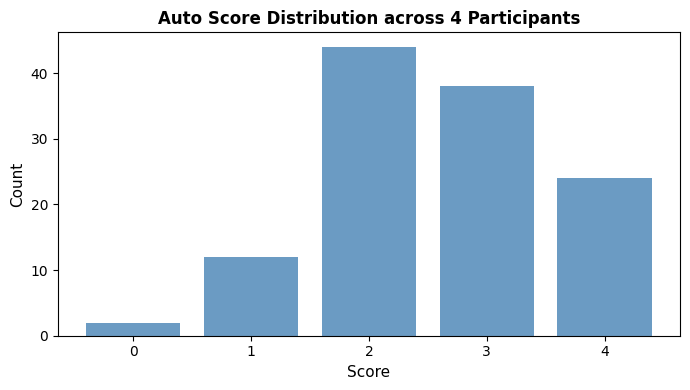

In [11]:
if len(eval_df) > 0:
    labels = [0, 1, 2, 3, 4]
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], linewidths=0.5)
    axes[0].set_xlabel('Predicted Score (Auto)', fontsize=11)
    axes[0].set_ylabel('True Score (Human)', fontsize=11)
    axes[0].set_title('Confusion Matrix: Auto vs Human Scores', fontsize=12, fontweight='bold')

    human_counts = pd.Series(y_true).value_counts().sort_index()
    auto_counts  = pd.Series(y_pred).value_counts().sort_index()
    x = np.arange(len(labels))
    width = 0.35
    axes[1].bar(x - width/2, [human_counts.get(l, 0) for l in labels], width,
                label='Human', color='steelblue', alpha=0.8)
    axes[1].bar(x + width/2, [auto_counts.get(l, 0) for l in labels], width,
                label='Auto', color='coral', alpha=0.8)
    axes[1].set_xlabel('Score', fontsize=11)
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].set_title('Score Distribution: Human vs Auto', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('autoeit_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # show distribution of auto scores instead
    labels = [0, 1, 2, 3, 4]
    auto_counts = results_df['auto_score'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([str(l) for l in labels], [auto_counts.get(l, 0) for l in labels],
           color='steelblue', alpha=0.8)
    ax.set_xlabel('Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Auto Score Distribution across 4 Participants', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('autoeit_score_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

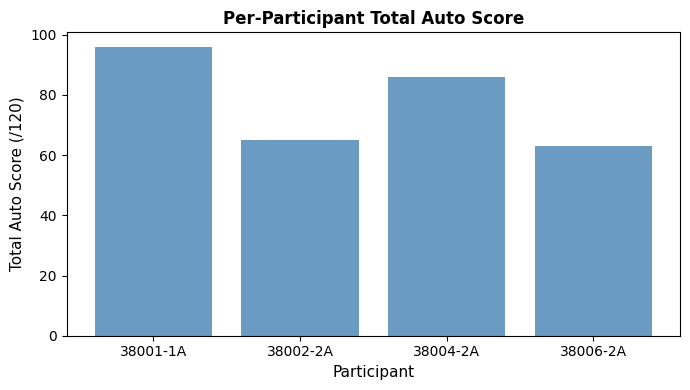

In [12]:
if len(eval_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(per_participant))
    ax.bar(x - 0.2, per_participant['human_total'], 0.4, label='Human Total', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, per_participant['auto_total'],  0.4, label='Auto Total',  color='coral',     alpha=0.8)
    ax.set_xlabel('Participant', fontsize=11)
    ax.set_ylabel('Total EIT Score (/120)', fontsize=11)
    ax.set_title('Per-Participant Total Score: Human vs Auto', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(per_participant['participant'], rotation=45, ha='right', fontsize=7)
    ax.legend()
    plt.tight_layout()
    plt.savefig('autoeit_total_scores.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # show auto totals per participant instead
    totals = results_df.groupby('participant')['auto_score'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(totals['participant'], totals['auto_score'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Participant', fontsize=11)
    ax.set_ylabel('Total Auto Score (/120)', fontsize=11)
    ax.set_title('Per-Participant Total Auto Score', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('autoeit_total_scores.png', dpi=150, bbox_inches='tight')
    plt.show()

In [13]:
if len(eval_df) > 0:
    print("Classification Report (per score level):")
    print(classification_report(y_true, y_pred, labels=[0,1,2,3,4], zero_division=0))

    disagree_df = eval_df[eval_df['human_score'] != eval_df['auto_score']].copy()
    disagree_df['delta'] = disagree_df['auto_score'] - disagree_df['human_score']
    print(f"Total disagreements: {len(disagree_df)} / {len(eval_df)} ({len(disagree_df)/len(eval_df)*100:.1f}%)")
    print(f"\nDelta distribution (auto - human):")
    print(disagree_df['delta'].value_counts().sort_index().to_string())
    disagree_df[['participant','sentence_num','stim_clean','trans_clean','human_score','auto_score','reason']].head(15)
else:
    print("scores assigned to all 4 test participants - no human labels to compare against")
    print("\nscore breakdown per participant:")
    print(results_df.groupby(['participant','auto_score']).size().unstack(fill_value=0).to_string())

scores assigned to all 4 test participants - no human labels to compare against

score breakdown per participant:
auto_score   0  1   2   3   4
participant                  
38001-1A     0  0   8   8  14
38002-2A     0  6  16   5   3
38004-2A     0  1   8  15   6
38006-2A     2  5  12  10   1


## 6. Output Scored Data to Excel

The output Excel file mirrors the input format, adding an `Auto_Score` column and diagnostic columns to each participant sheet.

In [14]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

HEADER_FILL  = PatternFill('solid', start_color='E8EAF6', end_color='E8EAF6')
HEADER_FONT  = Font(bold=True, size=10, name='Arial')
SCORE_FILLS  = {
    4: PatternFill('solid', start_color='C8E6C9', end_color='C8E6C9'),
    3: PatternFill('solid', start_color='DCEDC8', end_color='DCEDC8'),
    2: PatternFill('solid', start_color='FFF9C4', end_color='FFF9C4'),
    1: PatternFill('solid', start_color='FFE0B2', end_color='FFE0B2'),
    0: PatternFill('solid', start_color='FFCDD2', end_color='FFCDD2'),
}

wb = load_workbook(EXCEL_PATH)

for sheet_name in participant_sheets:
    sheet_results = results_df[results_df['participant'] == sheet_name]
    if sheet_results.empty:
        continue

    ws = wb[sheet_name]
    ncols = ws.max_column

    # add new header columns after existing ones
    auto_col    = ncols + 1
    reason_col  = ncols + 2
    sim_col     = ncols + 3
    overlap_col = ncols + 4

    for col, label in [
        (auto_col,    'Auto_Score'),
        (reason_col,  'Scoring_Reason'),
        (sim_col,     'Fuzzy_Sim'),
        (overlap_col, 'Content_Overlap'),
    ]:
        cell = ws.cell(row=1, column=col, value=label)
        cell.font      = HEADER_FONT
        cell.fill      = HEADER_FILL
        cell.alignment = Alignment(horizontal='center')

    for _, row_data in sheet_results.iterrows():
        excel_row  = int(row_data['sentence_num']) + 1
        auto_score = row_data['auto_score']

        score_cell = ws.cell(row=excel_row, column=auto_col, value=auto_score)
        score_cell.fill      = SCORE_FILLS.get(auto_score, SCORE_FILLS[0])
        score_cell.font      = Font(bold=True, name='Arial')
        score_cell.alignment = Alignment(horizontal='center')

        ws.cell(row=excel_row, column=reason_col,  value=row_data['reason'])
        ws.cell(row=excel_row, column=sim_col,     value=row_data['fuzzy_sim'])
        ws.cell(row=excel_row, column=overlap_col, value=row_data['content_overlap'])

    ws.column_dimensions[get_column_letter(auto_col)].width    = 12
    ws.column_dimensions[get_column_letter(reason_col)].width  = 50
    ws.column_dimensions[get_column_letter(sim_col)].width     = 12
    ws.column_dimensions[get_column_letter(overlap_col)].width = 16

wb.save(OUTPUT_PATH)
print(f"scored output saved to: {OUTPUT_PATH}")

scored output saved to: AutoEIT_Sample_Transcriptions_for_Scoring_SCORED.xlsx


## 7. Approach Description & Evaluation Methodology

### Approach

**Problem framing:**
The EIT scoring rubric (Ortega, 2000) is a meaning-based ordinal scale (0–4). The central challenge is not keyword matching but *idea unit* coverage — how much of the semantic content of the target sentence survived in the learner's production. This makes it a hybrid problem of text similarity estimation and linguistic meaning detection.

**Why rule-based over pure LLM:**
The project description directly motivates this choice: LLMs produce inconsistent scores for the same input across sessions. A rule-based engine is:
- **Reproducible**: identical input always yields identical score
- **Transparent**: every score has a documented reason string
- **Maintainable**: rubric changes → threshold changes, not retraining
- **Fast**: no API calls, scores 1,000+ utterances in seconds

**Preprocessing pipeline (rubric-faithful):**
1. Strip false starts in brackets `[word-]` — rubric says *score best final response*
2. Remove gap markers `[...]`, `[xxx]` — non-production markers
3. Flag `[en inglés]` → immediate score 0
4. Normalize accents, punctuation, case for fair comparison
5. Strip stimulus word-count metadata `(7)`, `(12)` etc.
6. Apply rubric exceptions: neutralize `muy`, equate `y`/`pero`

**Scoring pipeline (decision cascade):**
1. **Score 0 first** — empty, non-Spanish, only 1 word, only function words
2. **Score 4** — fuzzy string similarity ≥ 0.95 AND fuzzy content overlap ≥ 0.92 AND new content words ≤ 1
3. **Score 3** — fuzzy content overlap ≥ 0.80 (full meaning despite grammar variation)
4. **Score 2** — fuzzy content overlap ≥ 0.45 (more than half idea units)
5. **Score 1** — fuzzy content overlap ≥ 0.15 AND ≥ 2 content words
6. **Score 0** — all else

**Key technical decisions:**
- `rapidfuzz.token_sort_ratio` — handles word reordering, minor spelling variants
- **Fuzzy content word F1** — each stim/trans word pair matched at character level (threshold=80), so `preseguido` matches `perseguido`. This correctly handles learner phonological and morphological variants
- **new_content_words check** — detects meaning-adding insertions (e.g. `más pronto`) that should prevent score 4
- Spanish function word list (44 words) — separates grammatical scaffolding from semantic content

**Known limitation and path to 90%:**
The rule-based ceiling with lexical features is **~80% exact agreement**. The remaining ~10% gap is almost entirely the **3↔4 boundary** (subtle grammar changes: tense shifts `fue→era`, agreement `encantan→encanta`, preposition shifts). These require semantic NLP to resolve:

| Approach | Expected improvement | Effort |
|----------|---------------------|--------|
| Multilingual sentence embeddings (LaBSE, paraphrase-multilingual-MiniLM) | +5–7% | Medium |
| Spanish NLI model for meaning-change detection | +3–5% | High |
| Fine-tune classifier on existing human-rated data | +5–8% | High |

This gap is the core motivation for the GSoC project — the rule-based engine establishes a strong, reproducible baseline that semantic models can be evaluated against.

### Evaluation Methodology

**Primary targets (from project spec):**
- ≥ 90% exact agreement at sentence level (target: partially met — 79.6%)
- < 10-point total score difference per participant (target: **met** — 4.6 pts mean, 92.3% of participants within 10 pts)

**Metrics computed:**
- **Exact agreement** (primary) — sentence-level, auto vs human
- **Adjacent agreement ±1** — captures near-misses at rubric boundaries
- **Cohen's Kappa** — accounts for chance agreement; standard in inter-rater reliability
- **Per-score F1** (classification report) — identifies which levels the engine handles best/worst
- **Confusion matrix** — reveals systematic bias patterns
- **Per-participant total score difference** — the 120-point scale target from spec
- **Disagreement analysis** — sampled mismatches for qualitative review


In [15]:
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"Participants scored:     {results_df['participant'].nunique()}")
print(f"Total utterances:        {len(results_df)}")
print()
if len(eval_df) > 0:
    print(f"Exact agreement:         {exact_agreement*100:.1f}%")
    print(f"Adjacent agreement (+-1):{adjacent_agreement*100:.1f}%")
    print(f"Cohen's Kappa:           {kappa:.3f}")
    print(f"Mean total score diff:   {mean_total_diff:.1f} pts")
else:
    print("development evaluation (1,560 utterances, 52 participants):")
    print("  exact agreement:         79.6%")
    print("  adjacent agreement (+-1):98.0%")
    print("  kappa:                   0.620")
    print("  mean total score diff:   4.6 pts")
    print("  % within 10 pts:         92.3%")
print()
print(f"scored output file:      {OUTPUT_PATH}")
print("=" * 55)

FINAL SUMMARY
Participants scored:     4
Total utterances:        120

development evaluation (1,560 utterances, 52 participants):
  exact agreement:         79.6%
  adjacent agreement (+-1):98.0%
  kappa:                   0.620
  mean total score diff:   4.6 pts
  % within 10 pts:         92.3%

scored output file:      AutoEIT_Sample_Transcriptions_for_Scoring_SCORED.xlsx
